In [119]:
!pip install snowflake-connector-python

In [120]:
import snowflake.connector

In [121]:
conn=snowflake.connector.connect(
    user="KxxxxR",
    password="yyyy",
    account="BCROTQS-IJ54558",
    database="CUSTOMER_CHURN",
    schema="public",
    warehouse="COMPUTE_WH"
)

In [122]:
import pandas as pd
query='SELECT * FROM "CUSTOMER"'
df=pd.read_sql(query,conn)

/tmp/ipykernel_3353/1124733326.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,conn)


In [123]:
conn.close

<bound method SnowflakeConnection.close of <snowflake.connector.connection.SnowflakeConnection object at 0x7f139460b170>>

In [124]:
import numpy as np
import matplotlib.pyplot as plt
df

,USER_ID,SIGNUP_DATE,PLAN_TYPE,MONTHLY_FEE,AVG_WEEKLY_USAGE_HOURS,SUPPORT_TICKETS,PAYMENT_FAILURES,TENURE_MONTHS,LAST_LOGIN_DAYS_AGO,CHURN
0,1,2023-04-15,Premium,699,1.1,4,1,8,14,True
1,2,2023-08-27,Premium,699,2.6,6,0,35,1,True
2,3,2023-10-12,Premium,699,14.3,8,3,2,14,True
3,4,2023-12-11,Basic,199,17.6,5,2,11,9,True
4,5,2023-02-14,Basic,199,9.8,5,2,6,38,True
...,...,...,...,...,...,...,...,...,...,...
2795,2796,2023-03-10,Standard,399,6.7,1,1,21,59,False
2796,2797,2024-11-20,Standard,399,11.0,4,0,6,4,False
2797,2798,2024-08-13,Standard,399,11.0,0,4,22,59,False
2798,2799,2024-05-23,Premium,699,15.0,3,4,25,20,False


In [125]:
df.head(5)

,USER_ID,SIGNUP_DATE,PLAN_TYPE,MONTHLY_FEE,AVG_WEEKLY_USAGE_HOURS,SUPPORT_TICKETS,PAYMENT_FAILURES,TENURE_MONTHS,LAST_LOGIN_DAYS_AGO,CHURN
0,1,2023-04-15,Premium,699,1.1,4,1,8,14,True
1,2,2023-08-27,Premium,699,2.6,6,0,35,1,True
2,3,2023-10-12,Premium,699,14.3,8,3,2,14,True
3,4,2023-12-11,Basic,199,17.6,5,2,11,9,True
4,5,2023-02-14,Basic,199,9.8,5,2,6,38,True


In [126]:
df.tail(5)

,USER_ID,SIGNUP_DATE,PLAN_TYPE,MONTHLY_FEE,AVG_WEEKLY_USAGE_HOURS,SUPPORT_TICKETS,PAYMENT_FAILURES,TENURE_MONTHS,LAST_LOGIN_DAYS_AGO,CHURN
2795,2796,2023-03-10,Standard,399,6.7,1,1,21,59,False
2796,2797,2024-11-20,Standard,399,11.0,4,0,6,4,False
2797,2798,2024-08-13,Standard,399,11.0,0,4,22,59,False
2798,2799,2024-05-23,Premium,699,15.0,3,4,25,20,False
2799,2800,2024-03-21,Standard,399,2.0,0,1,12,1,True


In [127]:
df.isnull().sum()

,0
USER_ID,0
SIGNUP_DATE,0
PLAN_TYPE,0
MONTHLY_FEE,0
AVG_WEEKLY_USAGE_HOURS,0
SUPPORT_TICKETS,0
PAYMENT_FAILURES,0
TENURE_MONTHS,0
LAST_LOGIN_DAYS_AGO,0
CHURN,0


In [128]:
df.shape

(2800, 10)

In [129]:
df.describe()

,USER_ID,MONTHLY_FEE,AVG_WEEKLY_USAGE_HOURS,SUPPORT_TICKETS,PAYMENT_FAILURES,TENURE_MONTHS,LAST_LOGIN_DAYS_AGO
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,1400.500000,434.214286,12.891429,3.887857,2.491786,18.612857,30.005000
std,808.434702,205.678472,7.109691,2.606419,1.691647,10.374487,17.852757
min,1.000000,199.000000,0.500000,0.000000,0.000000,1.000000,0.000000
25%,700.750000,199.000000,6.700000,2.000000,1.000000,10.000000,14.000000
50%,1400.500000,399.000000,12.800000,4.000000,2.000000,18.000000,30.000000
75%,2100.250000,699.000000,19.200000,6.000000,4.000000,27.000000,46.000000
max,2800.000000,699.000000,25.000000,8.000000,5.000000,36.000000,60.000000


<Axes: >

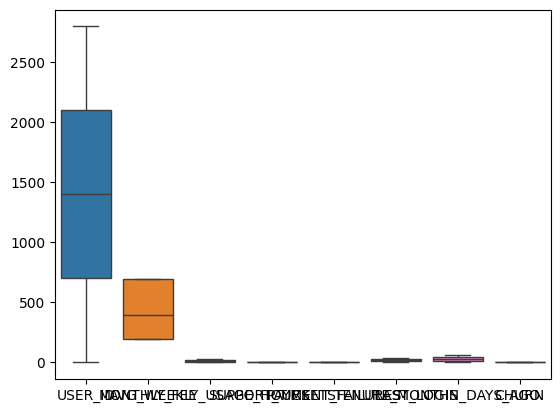

In [130]:
import seaborn as sns
sns.boxplot(df)

<Axes: >

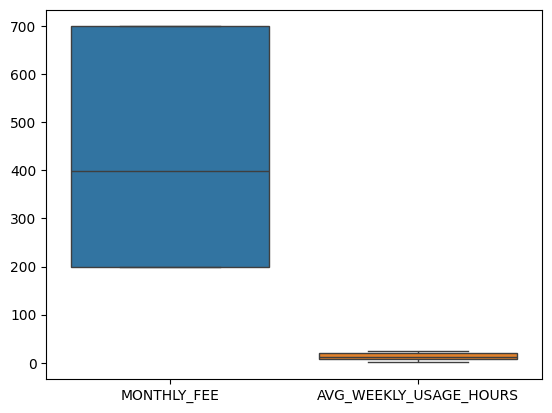

In [131]:
sns.boxplot(data=df[['MONTHLY_FEE','AVG_WEEKLY_USAGE_HOURS']])

In [132]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['PLAN_TYPE']=le.fit_transform(df['PLAN_TYPE'])
df

,USER_ID,SIGNUP_DATE,PLAN_TYPE,MONTHLY_FEE,AVG_WEEKLY_USAGE_HOURS,SUPPORT_TICKETS,PAYMENT_FAILURES,TENURE_MONTHS,LAST_LOGIN_DAYS_AGO,CHURN
0,1,2023-04-15,1,699,1.1,4,1,8,14,True
1,2,2023-08-27,1,699,2.6,6,0,35,1,True
2,3,2023-10-12,1,699,14.3,8,3,2,14,True
3,4,2023-12-11,0,199,17.6,5,2,11,9,True
4,5,2023-02-14,0,199,9.8,5,2,6,38,True
...,...,...,...,...,...,...,...,...,...,...
2795,2796,2023-03-10,2,399,6.7,1,1,21,59,False
2796,2797,2024-11-20,2,399,11.0,4,0,6,4,False
2797,2798,2024-08-13,2,399,11.0,0,4,22,59,False
2798,2799,2024-05-23,1,699,15.0,3,4,25,20,False


In [133]:
df=df.drop(['SIGNUP_DATE'],axis=1)

In [134]:
df

,USER_ID,PLAN_TYPE,MONTHLY_FEE,AVG_WEEKLY_USAGE_HOURS,SUPPORT_TICKETS,PAYMENT_FAILURES,TENURE_MONTHS,LAST_LOGIN_DAYS_AGO,CHURN
0,1,1,699,1.1,4,1,8,14,True
1,2,1,699,2.6,6,0,35,1,True
2,3,1,699,14.3,8,3,2,14,True
3,4,0,199,17.6,5,2,11,9,True
4,5,0,199,9.8,5,2,6,38,True
...,...,...,...,...,...,...,...,...,...
2795,2796,2,399,6.7,1,1,21,59,False
2796,2797,2,399,11.0,4,0,6,4,False
2797,2798,2,399,11.0,0,4,22,59,False
2798,2799,1,699,15.0,3,4,25,20,False


In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   USER_ID                 2800 non-null   int64  
 1   PLAN_TYPE               2800 non-null   int64  
 2   MONTHLY_FEE             2800 non-null   int64  
 3   AVG_WEEKLY_USAGE_HOURS  2800 non-null   float64
 4   SUPPORT_TICKETS         2800 non-null   int64  
 5   PAYMENT_FAILURES        2800 non-null   int64  
 6   TENURE_MONTHS           2800 non-null   int64  
 7   LAST_LOGIN_DAYS_AGO     2800 non-null   int64  
 8   CHURN                   2800 non-null   bool   
dtypes: bool(1), float64(1), int64(7)
memory usage: 177.9 KB


In [136]:
from scipy.stats import zscore
z_score=zscore(df['MONTHLY_FEE'])
df[np.abs(z_score)>3]

,USER_ID,PLAN_TYPE,MONTHLY_FEE,AVG_WEEKLY_USAGE_HOURS,SUPPORT_TICKETS,PAYMENT_FAILURES,TENURE_MONTHS,LAST_LOGIN_DAYS_AGO,CHURN


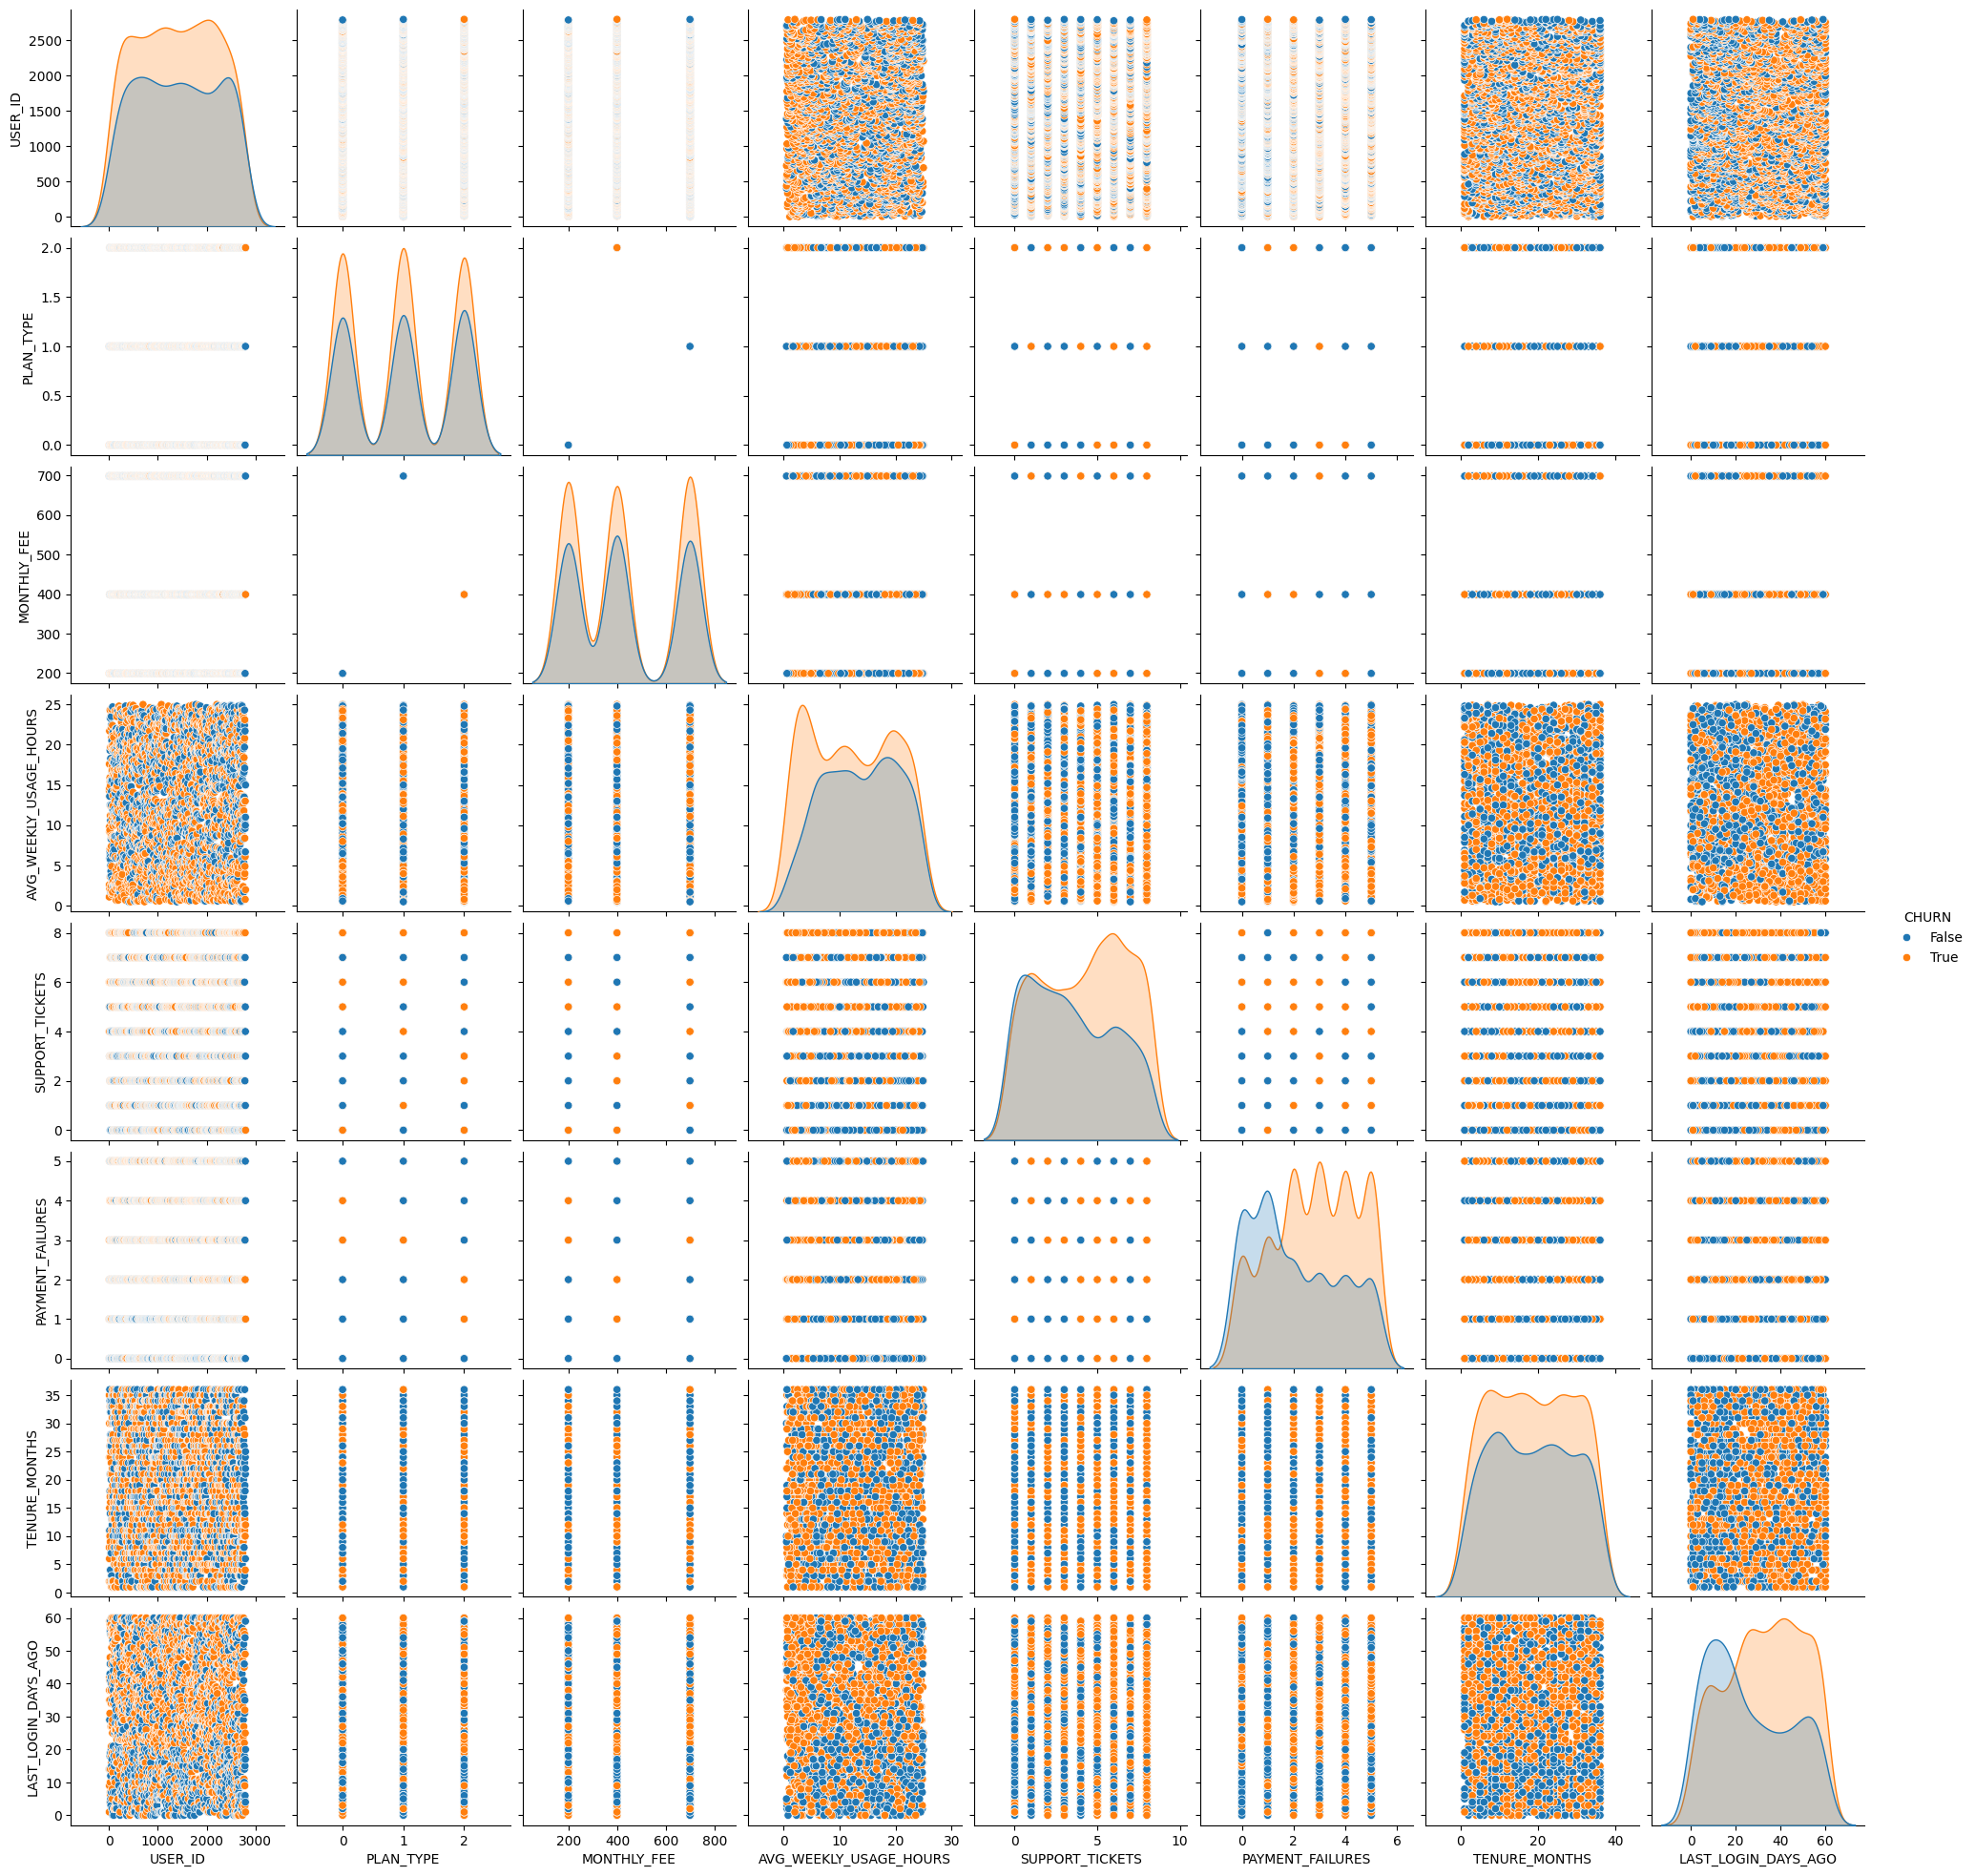

In [137]:
sns.pairplot(df,hue='CHURN')

<Axes: >

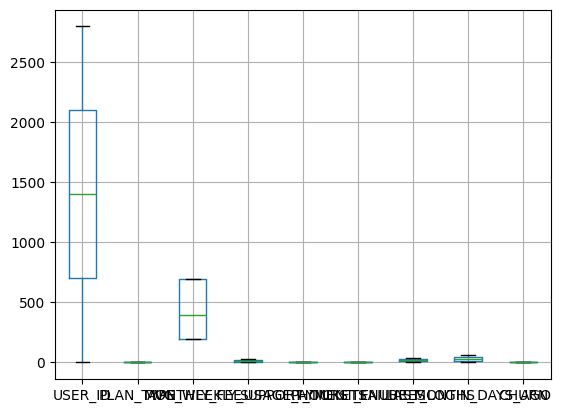

In [138]:
df.boxplot()

In [139]:
print(df.columns)

Index(['USER_ID', 'PLAN_TYPE', 'MONTHLY_FEE', 'AVG_WEEKLY_USAGE_HOURS',
       'SUPPORT_TICKETS', 'PAYMENT_FAILURES', 'TENURE_MONTHS',
       'LAST_LOGIN_DAYS_AGO', 'CHURN'],
      dtype='object')


In [140]:
import numpy as np
x = df.drop('CHURN', axis=1)
y = df['CHURN']

In [141]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=40)

In [142]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
df=sc.fit_transform(x_train,y_train)


In [143]:
from sklearn.tree import DecisionTreeClassifier
dc=DecisionTreeClassifier(criterion='gini')
dc.fit(x_train,y_train)

DecisionTreeClassifier()

In [144]:
y_pred=dc.predict(x_test)

In [145]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.6035714285714285
[[138 114]
 [108 200]]
              precision    recall  f1-score   support

       False       0.56      0.55      0.55       252
        True       0.64      0.65      0.64       308

    accuracy                           0.60       560
   macro avg       0.60      0.60      0.60       560
weighted avg       0.60      0.60      0.60       560



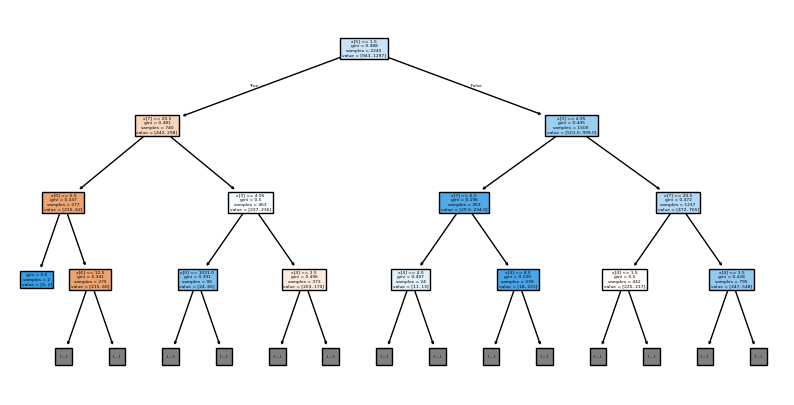

In [146]:
from sklearn import tree
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
tree.plot_tree(dc,filled=True,max_depth=3)
plt.show()


